In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np
import random
import time

In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [5]:
from torch.utils.data import Subset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_dataset_full = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

eval_dataset_full = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=eval_transform
)

print("Total images:", len(train_dataset_full))
print("Classes:", train_dataset_full.classes)

Total images: 50000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(len(train_dataset_full), generator=generator)[:5000]

train_indices = indices[:4000]
val_indices = indices[4000:]

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(eval_dataset_full, val_indices)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 4000
Validation images: 1000


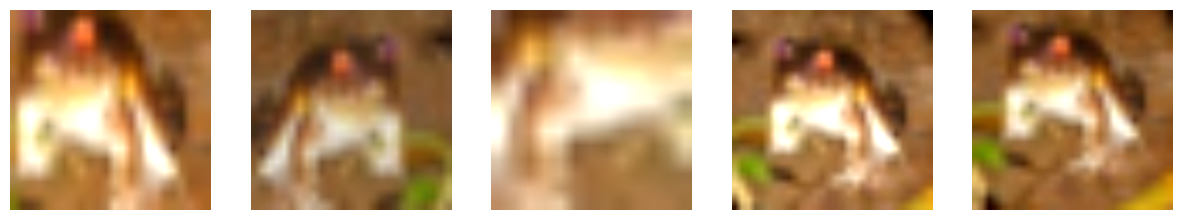

In [7]:
# Get one original CIFAR-10 image
image, label = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False
)[0]

# Show 5 training-transform versions
plt.figure(figsize=(15, 3))

for i in range(5):
    img = train_transform(image)

    # Undo normalization for display
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)

    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

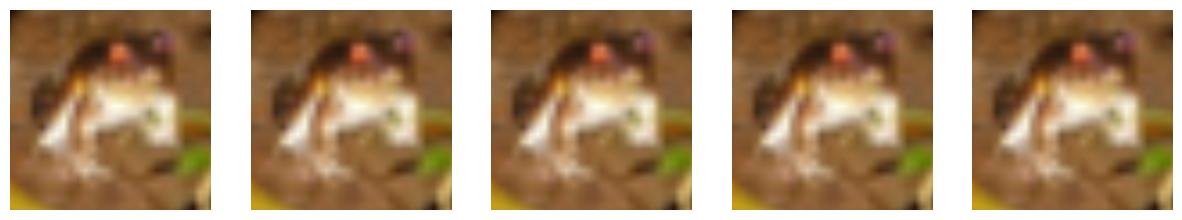

In [8]:
plt.figure(figsize=(15, 3))

for i in range(5):
    img = eval_transform(image)

    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)

    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [9]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 125
Validation batches: 32


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

# Freeze all pretrained parameters
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer for CIFAR-10
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

print("Device:", device)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\lenovo/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:05<00:00, 8.27MB/s]


Device: cpu
Linear(in_features=512, out_features=10, bias=True)


In [11]:
criterion = nn.CrossEntropyLoss()

trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=1e-3
)

num_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("Trainable parameters:", num_trainable_params)

Trainable parameters: 5130


In [12]:
num_epochs = 3

start_time = time.time()

for epoch in range(num_epochs):

    # Keep frozen backbone in evaluation mode
    model.eval()
    model.fc.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        "Epoch",
        epoch + 1,
        "Loss:",
        running_loss / len(train_loader)
    )

feature_extraction_time = time.time() - start_time

print("Training time:", feature_extraction_time, "seconds")

Epoch 1 Loss: 1.5388442211151123
Epoch 2 Loss: 1.1234170756340027
Epoch 3 Loss: 1.0171192278862
Training time: 552.728357553482 seconds


In [13]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

feature_extraction_accuracy = correct / total

print("Validation Accuracy:", feature_extraction_accuracy)
print("Training Time:", feature_extraction_time, "seconds")
print("Trainable Parameters:", num_trainable_params)

Validation Accuracy: 0.769
Training Time: 552.728357553482 seconds
Trainable Parameters: 5130


In [14]:
torch.manual_seed(SEED)

fine_model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

# Freeze all pretrained parameters
for param in fine_model.parameters():
    param.requires_grad = False

# Unfreeze the last block
for param in fine_model.layer4.parameters():
    param.requires_grad = True

# Replace the final layer for CIFAR-10
fine_model.fc = nn.Linear(fine_model.fc.in_features, 10)

fine_model = fine_model.to(device)

fine_trainable_params = sum(
    p.numel() for p in fine_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", fine_trainable_params)

Trainable parameters: 8398858


In [16]:
fine_criterion = nn.CrossEntropyLoss()

fine_optimizer = torch.optim.AdamW([
    {'params': fine_model.fc.parameters(), 'lr': 1e-3},
    {'params': fine_model.layer4.parameters(), 'lr': 1e-5}
])

print("Head learning rate:", 1e-3)
print("Layer4 learning rate:", 1e-5)
print("Trainable parameters:", fine_trainable_params)

Head learning rate: 0.001
Layer4 learning rate: 1e-05
Trainable parameters: 8398858


In [17]:
num_epochs = 3

start_time = time.time()

for epoch in range(num_epochs):

    fine_model.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        fine_optimizer.zero_grad()

        outputs = fine_model(images)

        loss = fine_criterion(outputs, labels)

        loss.backward()

        fine_optimizer.step()

        running_loss += loss.item()

    print(
        "Epoch",
        epoch + 1,
        "Loss:",
        running_loss / len(train_loader)
    )

fine_tuning_time = time.time() - start_time

print("Training time:", fine_tuning_time, "seconds")

Epoch 1 Loss: 1.778746950149536
Epoch 2 Loss: 1.2911898698806763
Epoch 3 Loss: 1.1933013243675232
Training time: 811.538179397583 seconds


In [18]:
fine_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = fine_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

fine_tuning_accuracy = correct / total

print("Validation Accuracy:", fine_tuning_accuracy)
print("Training Time:", fine_tuning_time, "seconds")
print("Trainable Parameters:", fine_trainable_params)

Validation Accuracy: 0.743
Training Time: 811.538179397583 seconds
Trainable Parameters: 8398858


In [19]:
print("Final Comparison")
print("------------------------------")

print("Feature Extraction")
print("Validation Accuracy:", feature_extraction_accuracy)
print("Training Time:", feature_extraction_time)
print("Trainable Parameters:", num_trainable_params)

print()

print("Fine-Tuning")
print("Validation Accuracy:", fine_tuning_accuracy)
print("Training Time:", fine_tuning_time)
print("Trainable Parameters:", fine_trainable_params)

Final Comparison
------------------------------
Feature Extraction
Validation Accuracy: 0.769
Training Time: 552.728357553482
Trainable Parameters: 5130

Fine-Tuning
Validation Accuracy: 0.743
Training Time: 811.538179397583
Trainable Parameters: 8398858


Conclusion

The feature extraction process reached a validation accuracy of 76.9%, while the fine-tuning process reached 74.3%. Thus, in this case, feature extraction worked better.

In the case of feature extraction, the pretrained ResNet-18 network was frozen, and only the new classification layer was trained. Pretrained features had some ability to classify images from the CIFAR-10 dataset.

In the case of fine-tuning, the last residual block was additionally updated. This made the number of trainable parameters greater and allowed the latter features to be adapted to CIFAR-10. However, in this case of a relatively small training set and three epochs of training, the result was worse.

It took more time to train fine-tuned parameters due to their larger number.